In [1]:
library(purrr)
library(tidyverse)
library(edgeR)

Warning message in system("timedatectl", intern = TRUE):
“running command 'timedatectl' had status 1”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.2     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: limma



In [2]:
# Read the csv file
#piRNAData <- read.csv("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/analysis/sRNA_deseq/seqCount/alinged_count_matrix_16.5dpc.txt", header = TRUE, row.names = 1,sep='\t')#, nrows = 10000)
#piRNAData 
# Read the csv file
#piRNAData <- read.csv("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/analysis/sRNA_deseq/seqCount/alinged_count_matrix_12.5dpp.txt", header = TRUE, row.names = 1,sep='\t')# nrows = 10000)
#piRNAData 
# Load necessary library
library(data.table)

# File path
file_path <- "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/analysis/sRNA_deseq/seqCount/alinged_count_matrix_12.5dpp.txt"

# Function to read a random sample of lines from a CSV file
read_random_lines_csv <- function(file_path, num_lines) {
  # Determine the total number of lines
  total_lines <- nrow(fread(file_path, select = 1, header = TRUE, sep = "\t"))

  # Ensure that the file has enough lines
  if (total_lines < num_lines) {
    stop("The file contains fewer lines than the requested sample size.")
  }

  # Generate random line numbers
  line_numbers <- sample(total_lines, num_lines)

  # Read only the selected lines
  read_lines <- fread(file_path, skip = line_numbers - 1, nrows = num_lines, header = TRUE, sep = "\t")
  
  return(read_lines)
}

# Read a random sample of 1000 lines
piRNAData <- read_random_lines_csv(file_path, 100000)
piRNAData




,X129S1_SvImJ.16.5dpc.1,X129S1_SvImJ.16.5dpc.2,X129S1_SvImJ.16.5dpc.3,A_J.16.5dpc.1,A_J.16.5dpc.2,A_J.16.5dpc.3,AKR_J.16.5dpc.1,AKR_J.16.5dpc.2,AKR_J.16.5dpc.3,BALB_cJ.16.5dpc.1,⋯,NZO_HlLtJ.16.5dpc.3,PWK_PhJ.16.5dpc.1,PWK_PhJ.16.5dpc.2,PWK_PhJ.16.5dpc.3,SPRET_EiJ.16.5dpc.1,SPRET_EiJ.16.5dpc.2,SPRET_EiJ.16.5dpc.3,WSB_EiJ.16.5dpc.1,WSB_EiJ.16.5dpc.2,WSB_EiJ.16.5dpc.3
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
TGTTAGCCTCTGTCAGCAGTCCTGGGA,29591,22889,27873,16269,10522,19222,117,80,92,8537,⋯,13301,626,614,793,28,41,17,15412,14958,16167
GCATTGGTGGTTCAGTGGTAGAATTCT,20442,35884,15747,55516,13690,27836,23944,24399,33949,131288,⋯,16125,20924,36847,37491,331200,463615,404511,241431,404017,346271
TGAAGAAACAGACTGGGAGAAAAAAGC,16646,18476,23149,23096,13013,31989,26111,25596,14870,7504,⋯,27437,1245,1821,2237,2629,6452,3044,50098,55692,64513
TCCGGTAGAATATGTGCAGATTAAATA,15977,14940,17151,47555,25914,41661,37065,33908,32594,26373,⋯,26352,8960,10086,11904,14,23,5,57141,57398,61360
TTGGAAGCAAGTAGAGCTATATGACCT,13564,17478,18582,1260,942,1878,10698,5834,7299,1734,⋯,2907,16449,18184,21709,0,0,0,6846,3731,3952
TACAGAGACAAGAATGACACGGACACC,13348,13133,12737,289,275,707,0,0,0,388,⋯,1481,0,0,0,0,0,0,3093,1846,1839
TGCTGGAAGCTGATTTAATTTTGTGCC,13070,11597,13448,15846,10624,19284,14905,16069,18256,13448,⋯,11100,21483,23718,27620,0,0,0,19294,14189,14409
TCACCCTGATGAACTGAATACCGCCCC,12351,25232,11921,41119,8683,24140,8717,16656,17099,75324,⋯,16118,12260,18978,15901,88585,177669,100022,124858,275590,300198
TATAAGGTTCCCGTAACACAGACTGTT,12037,11768,13112,14649,7761,13596,8298,12338,12493,2423,⋯,20940,11540,13551,17622,1666,5681,3770,25512,25758,24811


In [3]:
sampleName = c('129S1_SvImJ-E16.5','129S1_SvImJ-E16.5','129S1_SvImJ-E16.5','A_J-E16.5','A_J-E16.5','A_J-E16.5','AKR_J-E16.5','AKR_J-E16.5','AKR_J-E16.5','BALB_cJ-E16.5','BALB_cJ-E16.5','BALB_cJ-E16.5','C3H_HeJ-E16.5','C3H_HeJ-E16.5','C3H_HeJ-E16.5','C57BL_6NJ-E16.5','C57BL_6NJ-E16.5','C57BL_6NJ-E16.5','CAST_EiJ-E16.5','CAST_EiJ-E16.5','CAST_EiJ-E16.5','CBA_J-E16.5','CBA_J-E16.5','CBA_J-E16.5','DBA_2J-E16.5','DBA_2J-E16.5','DBA_2J-E16.5','FVB_NJ-E16.5','FVB_NJ-E16.5','FVB_NJ-E16.5','LP_J-E16.5','LP_J-E16.5','LP_J-E16.5','NOD_ShiLtJ-E16.5','NOD_ShiLtJ-E16.5','NOD_ShiLtJ-E16.5','NZO_HlLtJ-E16.5','NZO_HlLtJ-E16.5','NZO_HlLtJ-E16.5','PWK_PhJ-E16.5','PWK_PhJ-E16.5','PWK_PhJ-E16.5','SPRET_EiJ-E16.5','SPRET_EiJ-E16.5','SPRET_EiJ-E16.5','WSB_EiJ-E16.5','WSB_EiJ-E16.5','WSB_EiJ-E16.5')

lablesName = c('129S1_SvImJ-E16.5.1','129S1_SvImJ-E16.5.2','129S1_SvImJ-E16.5.3','A_J-E16.5.1','A_J-E16.5.2','A_J-E16.5.3','AKR_J-E16.5.1','AKR_J-E16.5.2','AKR_J-E16.5.3','BALB_cJ-E16.5.1','BALB_cJ-E16.5.2','BALB_cJ-E16.5.3','C3H_HeJ-E16.5.1','C3H_HeJ-E16.5.2','C3H_HeJ-E16.5.3','C57BL_6NJ-E16.5.1','C57BL_6NJ-E16.5.2','C57BL_6NJ-E16.5.3','CAST_EiJ-E16.5.1','CAST_EiJ-E16.5.2','CAST_EiJ-E16.5.3','CBA_J-E16.5.1','CBA_J-E16.5.2','CBA_J-E16.5.3','DBA_2J-E16.5.1','DBA_2J-E16.5.2','DBA_2J-E16.5.3','FVB_NJ-E16.5.1','FVB_NJ-E16.5.2','FVB_NJ-E16.5.3','LP_J-E16.5.1','LP_J-E16.5.2','LP_J-E16.5.3','NOD_ShiLtJ-E16.5.1','NOD_ShiLtJ-E16.5.2','NOD_ShiLtJ-E16.5.3','NZO_HlLtJ-E16.5.1','NZO_HlLtJ-E16.5.2','NZO_HlLtJ-E16.5.3','PWK_PhJ-E16.5.1','PWK_PhJ-E16.5.2','PWK_PhJ-E16.5.3','SPRET_EiJ-E16.5.1','SPRET_EiJ-E16.5.2','SPRET_EiJ-E16.5.3','WSB_EiJ-E16.5.1','WSB_EiJ-E16.5.2','WSB_EiJ-E16.5.3')

#samplenames = tools::file_path_sans_ext(tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T)))
sampleNames_order = c('C57BL_6NJ-E16.5','C57BL_6NJ-E16.5','C57BL_6NJ-E16.5',
'BALB_cJ-E16.5','BALB_cJ-E16.5','BALB_cJ-E16.5',
'A_J-E16.5','A_J-E16.5','A_J-E16.5',
'FVB_NJ-E16.5','FVB_NJ-E16.5','FVB_NJ-E16.5',
'C3H_HeJ-E16.5','C3H_HeJ-E16.5','C3H_HeJ-E16.5',
'129S1_SvImJ-E16.5','129S1_SvImJ-E16.5','129S1_SvImJ-E16.5',
'DBA_2J-E16.5','DBA_2J-E16.5','DBA_2J-E16.5',
'AKR_J-E16.5','AKR_J-E16.5','AKR_J-E16.5',
'CBA_J-E16.5','CBA_J-E16.5','CBA_J-E16.5',
'NOD_ShiLtJ-E16.5','NOD_ShiLtJ-E16.5','NOD_ShiLtJ-E16.5',
'WSB_EiJ-E16.5','WSB_EiJ-E16.5','WSB_EiJ-E16.5',
'CAST_EiJ-E16.5','CAST_EiJ-E16.5','CAST_EiJ-E16.5',
'PWK_PhJ-E16.5','PWK_PhJ-E16.5','PWK_PhJ-E16.5',
'SPRET_EiJ-E16.5','SPRET_EiJ-E16.5','SPRET_EiJ-E16.5')

lablesName_order = c('C57BL_6NJ-E16.5.1','C57BL_6NJ-E16.5.2','C57BL_6NJ-E16.5.3',
'BALB_cJ-E16.5.1','BALB_cJ-E16.5.2','BALB_cJ-E16.5.3',
'A_J-E16.5.1','A_J-E16.5.2','A_J-E16.5.3',
'FVB_NJ-E16.5.1','FVB_NJ-E16.5.2','FVB_NJ-E16.5.3',
'C3H_HeJ-E16.5.1','C3H_HeJ-E16.5.2','C3H_HeJ-E16.5.3',
'129S1_SvImJ-E16.5.1','129S1_SvImJ-E16.5.2','129S1_SvImJ-E16.5.3',
'DBA_2J-E16.5.1','DBA_2J-E16.5.2','DBA_2J-E16.5.3',
'AKR_J-E16.5.1','AKR_J-E16.5.2','AKR_J-E16.5.3',
'CBA_J-E16.5.1','CBA_J-E16.5.2','CBA_J-E16.5.3',
'NOD_ShiLtJ-E16.5.1','NOD_ShiLtJ-E16.5.2','NOD_ShiLtJ-E16.5.3',
'WSB_EiJ-E16.5.1','WSB_EiJ-E16.5.2','WSB_EiJ-E16.5.3',
'CAST_EiJ-E16.5.1','CAST_EiJ-E16.5.2','CAST_EiJ-E16.5.3',
'PWK_PhJ-E16.5.1','PWK_PhJ-E16.5.2','PWK_PhJ-E16.5.3',
'SPRET_EiJ-E16.5.1','SPRET_EiJ-E16.5.2','SPRET_EiJ-E16.5.3')

In [4]:
#change columns names 

colnames(piRNAData) <- lablesName 
piRNAData 

,129S1_SvImJ-E16.5.1,129S1_SvImJ-E16.5.2,129S1_SvImJ-E16.5.3,A_J-E16.5.1,A_J-E16.5.2,A_J-E16.5.3,AKR_J-E16.5.1,AKR_J-E16.5.2,AKR_J-E16.5.3,BALB_cJ-E16.5.1,⋯,NZO_HlLtJ-E16.5.3,PWK_PhJ-E16.5.1,PWK_PhJ-E16.5.2,PWK_PhJ-E16.5.3,SPRET_EiJ-E16.5.1,SPRET_EiJ-E16.5.2,SPRET_EiJ-E16.5.3,WSB_EiJ-E16.5.1,WSB_EiJ-E16.5.2,WSB_EiJ-E16.5.3
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
TGTTAGCCTCTGTCAGCAGTCCTGGGA,29591,22889,27873,16269,10522,19222,117,80,92,8537,⋯,13301,626,614,793,28,41,17,15412,14958,16167
GCATTGGTGGTTCAGTGGTAGAATTCT,20442,35884,15747,55516,13690,27836,23944,24399,33949,131288,⋯,16125,20924,36847,37491,331200,463615,404511,241431,404017,346271
TGAAGAAACAGACTGGGAGAAAAAAGC,16646,18476,23149,23096,13013,31989,26111,25596,14870,7504,⋯,27437,1245,1821,2237,2629,6452,3044,50098,55692,64513
TCCGGTAGAATATGTGCAGATTAAATA,15977,14940,17151,47555,25914,41661,37065,33908,32594,26373,⋯,26352,8960,10086,11904,14,23,5,57141,57398,61360
TTGGAAGCAAGTAGAGCTATATGACCT,13564,17478,18582,1260,942,1878,10698,5834,7299,1734,⋯,2907,16449,18184,21709,0,0,0,6846,3731,3952
TACAGAGACAAGAATGACACGGACACC,13348,13133,12737,289,275,707,0,0,0,388,⋯,1481,0,0,0,0,0,0,3093,1846,1839
TGCTGGAAGCTGATTTAATTTTGTGCC,13070,11597,13448,15846,10624,19284,14905,16069,18256,13448,⋯,11100,21483,23718,27620,0,0,0,19294,14189,14409
TCACCCTGATGAACTGAATACCGCCCC,12351,25232,11921,41119,8683,24140,8717,16656,17099,75324,⋯,16118,12260,18978,15901,88585,177669,100022,124858,275590,300198
TATAAGGTTCCCGTAACACAGACTGTT,12037,11768,13112,14649,7761,13596,8298,12338,12493,2423,⋯,20940,11540,13551,17622,1666,5681,3770,25512,25758,24811


In [5]:
setwd("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/analysis/sRNA_deseq/seqCount")

In [6]:
# Now we build a DESeq2 Count dataset and normalize it.
library(DESeq2)
library(gplots)
library(RColorBrewer)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggrepel)
library(BiocParallel)
# Register 10 cores for parallel processing
register(MulticoreParam(workers = 10))

conds = data.frame(sampleName) ##what Desq2 manual calls coldata
colnames(conds)="sample"
cds <- DESeqDataSetFromMatrix(countData = piRNAData , colData = conds, design = ~ sample)
#cds <- estimateSizeFactors(cds)
#cds <- estimateDispersions(cds)
#cds <- nbinomWaldTest(cds)
cds <- DESeq(cds, parallel = TRUE)

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:limma’:

    plotMA


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following objec

In [7]:
norm_counts <-counts(cds,normalized=TRUE)
norm_counts

,129S1_SvImJ-E16.5.1,129S1_SvImJ-E16.5.2,129S1_SvImJ-E16.5.3,A_J-E16.5.1,A_J-E16.5.2,A_J-E16.5.3,AKR_J-E16.5.1,AKR_J-E16.5.2,AKR_J-E16.5.3,BALB_cJ-E16.5.1,⋯,NZO_HlLtJ-E16.5.3,PWK_PhJ-E16.5.1,PWK_PhJ-E16.5.2,PWK_PhJ-E16.5.3,SPRET_EiJ-E16.5.1,SPRET_EiJ-E16.5.2,SPRET_EiJ-E16.5.3,WSB_EiJ-E16.5.1,WSB_EiJ-E16.5.2,WSB_EiJ-E16.5.3
TGTTAGCCTCTGTCAGCAGTCCTGGGA,25517.091,19633.532,21575.528,13218.3764,12943.1296,12906.4555,98.694696,84.768724,85.678541,7247.5627,⋯,14427.014,526.804744,464.669548,502.392944,2.536533e+01,3.490126e+01,2.374604e+01,11380.32649,15439.26067,16478.7929
GCATTGGTGGTTCAGTGGTAGAATTCT,17627.670,30780.272,12189.209,45106.1149,16840.0916,18690.2558,20197.827424,25853.401185,31616.312823,111458.1256,⋯,17490.083,17608.406495,27885.470433,23751.846005,3.000357e+05,3.946524e+05,5.650314e+05,178274.30609,417015.89652,352949.1003
TGAAGAAACAGACTGGGAGAAAAAAGC,14354.280,15848.186,17918.842,18765.2358,16007.3128,21478.7538,22025.788167,27121.753216,13848.259792,6370.5881,⋯,29759.715,1047.718700,1378.116038,1417.216919,2.381624e+03,5.492266e+03,4.251938e+03,36992.70676,57483.84179,65757.1824
TCCGGTAGAATATGTGCAGATTAAATA,13777.384,12815.106,13275.997,38637.8935,31876.8543,27972.9396,31265.973667,35929.223631,30354.416924,22389.5950,⋯,28582.863,7540.208478,7632.991961,7541.595979,1.268267e+01,1.957875e+01,6.984129e+00,42193.30626,59244.73086,62543.3744
TTGGAAGCAAGTAGAGCTATATGACCT,11696.591,14992.130,14383.685,1023.7356,1158.7558,1260.9678,9024.238130,6181.759191,6797.474662,1472.0949,⋯,3153.096,13842.509961,13761.483821,13753.402814,0.000000e+00,0.000000e+00,0.000000e+00,5055.13335,3851.04169,4028.2173
TACAGAGACAAGAATGACACGGACACC,11510.329,11265.113,9859.272,234.8092,338.2780,474.7094,0.000000,0.000000,0.000000,329.3961,⋯,1606.376,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,2283.89241,1905.39345,1874.4665
TGCTGGAAGCTGATTTAATTTTGTGCC,11270.602,9947.576,10409.633,12874.6937,13068.6000,12948.0849,12573.029475,17026.857807,17001.602607,11416.8003,⋯,12039.685,18078.827983,17949.564082,17498.225885,0.000000e+00,0.000000e+00,0.000000e+00,14246.82191,14645.51877,14686.8886
TCACCCTGATGAACTGAATACCGCCCC,10650.590,21643.290,9227.635,33408.7171,10680.9727,16208.6066,7353.176648,17648.848319,15924.101828,63946.9856,⋯,17482.491,10317.294190,14362.375713,10073.833809,8.024957e+04,1.512408e+05,1.397133e+05,92196.00345,284456.86919,305987.5473
TATAAGGTTCCCGTAACACAGACTGTT,10379.819,10094.255,10149.547,11902.1449,9546.8189,9128.9236,6999.731539,13073.456446,11634.587060,2057.0276,⋯,22712.703,9711.384580,10255.272067,11164.146870,1.509237e+03,4.835952e+03,5.266033e+03,18838.23576,26586.74131,25289.4991
TATAAGGATATACACTGGCTTTGGTCT,10215.115,10462.239,10397.248,12946.1927,12417.8762,11695.1744,11529.565036,10945.761475,10674.428630,6872.3229,⋯,7465.689,11942.310102,14397.944880,14086.642018,4.257752e+01,1.447125e+01,2.793652e+00,12945.01062,16285.64346,15325.9807


In [8]:
library(MGFR)
markers.list <- getMarkerGenes.rnaseq(norm_counts, class.vec = sampleName ,samples2compare="all",score.cuto=0.5)

write.csv(t(sapply(markers.list, unlist)), file = "E16.5_marker_alinged.tab")
write.csv(rapply(markers.list, length, how="list"), file = "E16.5_marker_alinged_count.tab")
# Convert the list to FASTA format with unique headers
convert_to_fasta <- function(data_list, output_file) {
  con <- file(output_file, "w")
  header_count <- list()
  
  for (name in names(data_list)) {
    sequences <- unlist(strsplit(data_list[[name]], "'"))
    
    for (seq_info in sequences) {
      split_data <- unlist(strsplit(seq_info, " : "))
      if(length(split_data) == 2) {
        sequence <- split_data[1]
        value <- split_data[2]
        
        # Construct the base header and then check for repetitions
        base_header <- paste(name, "_", value, sep="")
        if (!base_header %in% names(header_count)) {
          header_count[[base_header]] <- 1
          header <- paste(">", base_header, sep="")
        } else {
          header_count[[base_header]] <- header_count[[base_header]] + 1
          header <- paste(">", base_header, "_", header_count[[base_header]], sep="")
        }
        
        cat(header, "\n", sequence, "\n", file=con)
      }
    }
  }
  close(con)
}

# Call the function to write to a FASTA file
convert_to_fasta(markers.list, "E16.5_marker_alinged.fasta")

Detecting marker genes...
Done! 


In [9]:
pdf("E16.5_deseq2_BarGraphBeforeAfter.pdf",paper="a4")
par(mfrow=c(2,1))

par(mar=c(10,4,0,2)) # increase y-axis margin.
prenorm=apply(piRNAData ,2,sum)
barplot(prenorm,col=as.factor(sampleName),las=2,names=sampleName, cex.names = 0.6, cex.axis = 0.8)
postnorm=apply(norm_counts ,2,sum)
barplot(postnorm,col=as.factor(sampleName),las=2,names=sampleName ,cex.names = 0.6, cex.axis = 0.8)
dev.off()




png 
  2

In [10]:
library(gplots)
library(RColorBrewer)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggrepel)

# Make a color scheme for heatmaps
hmcol = colorRampPalette(brewer.pal(9, "GnBu"))(100)
# First we tell DESeq which samples correspond to which tissues.

pdf("E16.5_InitialHeatMap.pdf",paper="special",width=15, height=15,title="E16,5",fillOddEven=T)
heatmap.2(cor(norm_counts),trace="none",col=hmcol,main="Sample Correlation",cexRow=1,cexCol=1,
    margins=c(15,15),na.rm=T,key=T,offsetRow=1,offsetCol=1,keysize=0.4,density.info='histogram')
dev.off()

png 
  2

In [11]:
##And the Spearman Dendogram

foo_cor_1 = cor(norm_counts, method = "spearman") #builds matrix of Spearman corrn and euclidean distances

foo_cor_dist_1 = dist(foo_cor_1, method = "euclidean")
pdf(file="E16.5_dendrogram.pdf", height=8, width=15)
plot(hclust(foo_cor_dist_1))
dev.off()

png 
  2


Attaching package: ‘gridExtra’


The following object is masked from ‘package:Biobase’:

    combine


The following object is masked from ‘package:BiocGenerics’:

    combine


The following object is masked from ‘package:dplyr’:

    combine




,PC1,PC2,PC3,Strains,Variance_PC1,Variance_PC2,Variance_PC3,Shape,Unique_Strains
,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
129S1_SvImJ-E16.5.1,-100704.5641,-30409.238,-7944.0707,129S1_SvImJ-E16.5,72.39437,16.06593,3.060906,E16.5,129S1_SvImJ
129S1_SvImJ-E16.5.2,-83942.0245,-29941.990,-4527.9130,129S1_SvImJ-E16.5,72.39437,16.06593,3.060906,E16.5,129S1_SvImJ
129S1_SvImJ-E16.5.3,-105064.6786,-25910.567,-6383.7670,129S1_SvImJ-E16.5,72.39437,16.06593,3.060906,E16.5,129S1_SvImJ
A_J-E16.5.1,-62281.3174,-15713.824,7150.2533,A_J-E16.5,72.39437,16.06593,3.060906,E16.5,A_J
A_J-E16.5.2,-100299.2727,-21010.526,-3328.1668,A_J-E16.5,72.39437,16.06593,3.060906,E16.5,A_J
A_J-E16.5.3,-95111.2397,-16142.461,-157.5019,A_J-E16.5,72.39437,16.06593,3.060906,E16.5,A_J
AKR_J-E16.5.1,-97888.2088,-20775.490,-7944.9200,AKR_J-E16.5,72.39437,16.06593,3.060906,E16.5,AKR_J
AKR_J-E16.5.2,-86115.7522,-9423.184,1722.3469,AKR_J-E16.5,72.39437,16.06593,3.060906,E16.5,AKR_J
AKR_J-E16.5.3,-84501.0311,-26119.869,-4087.7863,AKR_J-E16.5,72.39437,16.06593,3.060906,E16.5,AKR_J


TableGrob (3 x 1) "arrange": 3 grobs
  z     cells    name           grob
1 1 (1-1,1-1) arrange gtable[layout]
2 2 (2-2,1-1) arrange gtable[layout]
3 3 (3-3,1-1) arrange gtable[layout]


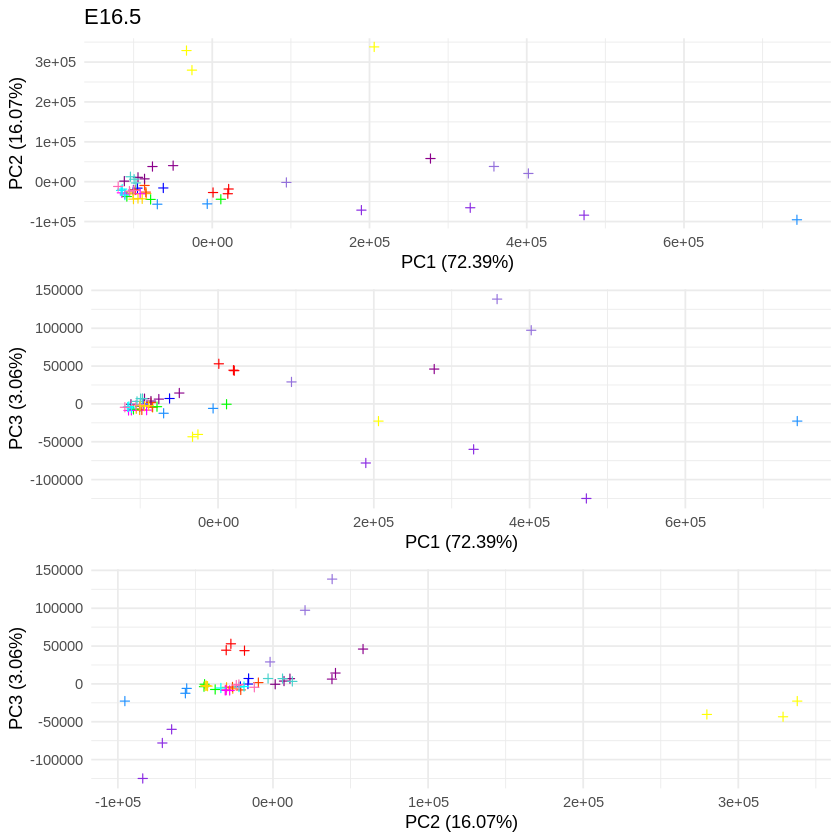

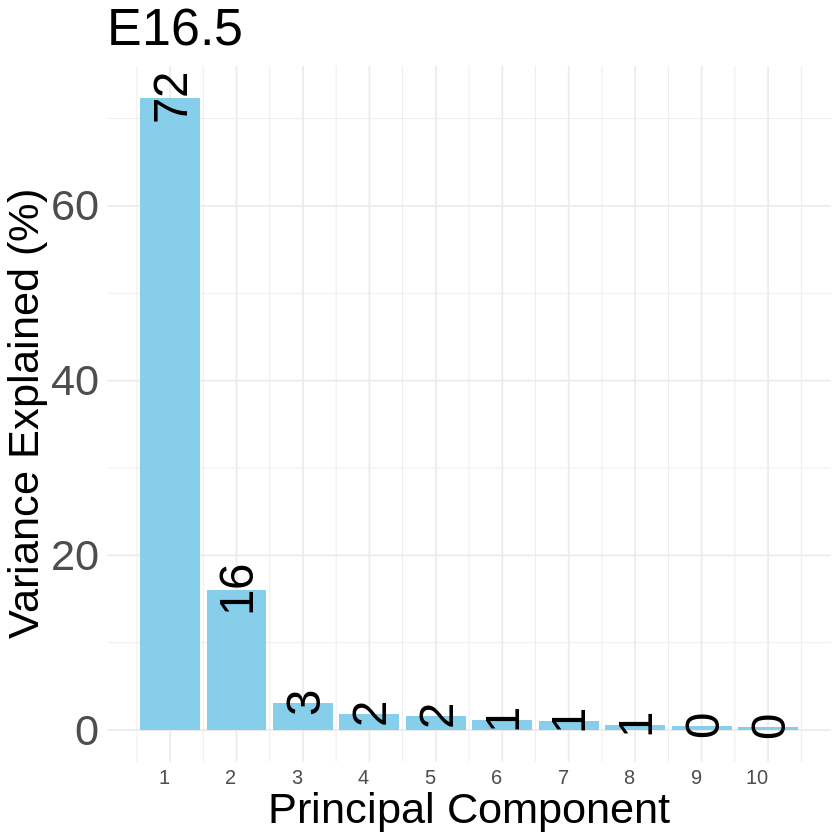

In [12]:
library(edgeR)
library(ggplot2)
library(gridExtra)

# Sample data for illustration purposes
set.seed(123)

samplenames_order =  c('C57BL_6NJ','C57BL_6NJ','C57BL_6NJ',
'BALB_cJ','BALB_cJ','BALB_cJ',
'A_J','A_J','A_J',
'FVB_NJ','FVB_NJ','FVB_NJ',
'C3H_HeJ','C3H_HeJ','C3H_HeJ','LP_J',
'129S1_SvImJ','129S1_SvImJ','129S1_SvImJ',
'DBA_2J','DBA_2J','DBA_2J',
'AKR_J','AKR_J','AKR_J',
'CBA_J','CBA_J','CBA_J',
'NOD_ShiLtJ','NOD_ShiLtJ','NOD_ShiLtJ','NZO_HlLtJ',
'WSB_EiJ','WSB_EiJ','WSB_EiJ',
'CAST_EiJ','CAST_EiJ','CAST_EiJ',
'PWK_PhJ','PWK_PhJ','PWK_PhJ',
'SPRET_EiJ','SPRET_EiJ','SPRET_EiJ')


# Perform PCA on normalized count data
pca <- prcomp(t(norm_counts))



# Calculate the variance explained by each PC
variance_explained <- pca$sdev^2 / sum(pca$sdev^2) * 100

# Generate a color palette based on the number of unique sample names

custom_colors <- c(
  '#FF0000',  # Bright Red
  '#00FF00',  # Bright Green
  '#0000FF',  # Bright Blue
  '#FF00FF',  # Bright Magenta
  '#FFFF00',  # Bright Yellow
  '#00FFFF',  # Bright Cyan
  '#FFA500',  # Orange
  '#800080',  # Purple
  '#FF4500',  # Deep Orange
  '#8B008B',  # Dark Magenta
  '#FF69B4',  # Hot Pink
  '#48D1CC',  # Teal
  '#9370DB',  # Lavender
  '#1E90FF',  # Royal Blue
  '#FFD700',  # Gold
  '#8A2BE2',  # Blue Violet
  '#FF6347',  # Tomato
  '#008000'   # Dark Green
)
# Create a data frame for PCA results and variance explained
pca_data <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], PC3 = pca$x[, 3], Strains = sampleName,
                       Variance_PC1 = variance_explained[1], Variance_PC2 = variance_explained[2], Variance_PC3 = variance_explained[3])

# Create individual PCA plots with unique colors
  # Create a new column 'Shape' based on the sample names
pca_data$Shape <- ifelse(grepl("12.5", pca_data$Strains ), "P12.5",
            ifelse(grepl("16.5", pca_data$Strains ), "E16.5",
                   ifelse(grepl("20.5", pca_data$Strains ), "P20.5", "D")))
# Extract unique strain names from the "Strains" column
pca_data$Unique_Strains <- sapply(strsplit(pca_data$Strains, "-"), function(x) x[1])

pca_data


# Calculate the variance explained by each PC
variance_explained <- pca$sdev^2 / sum(pca$sdev^2) * 100




# Create individual PCA plots with unique colors
# Create individual PCA plots with unique colors and shapes for the legend
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs(title = "E16.5", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +
  theme_minimal() + labs(shape = "Timepoint")  +
  theme(legend.position = "none") 

pca_plot_pc1_pc3 <- ggplot(pca_data, aes(x = PC1, y = PC3, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs( x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[3], 2), "%)", sep = "")) +
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +
  theme_minimal() + labs(shape = "Timepoint")  +
  theme(legend.position = "none") 


pca_plot_pc2_pc3 <- ggplot(pca_data, aes(x = PC2, y = PC3, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs( x = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[3], 2), "%)", sep = "")) +
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +
  theme_minimal() + labs(shape = "Timepoint")  +
  theme(legend.position = "none") 






# Create a custom layout matrix for vertical arrangement
layout_mat <- rbind(c(1), c(2), c(3))
# Define custom widths for each plot
custom_widths <- c(15, 15, 15)  # Adjust these values as needed
custom_heights <- c(3, 3, 3) 

# Create the grid of PCA plots
grid <- grid.arrange(pca_plot_pc1_pc2, pca_plot_pc1_pc3, pca_plot_pc2_pc3,
                     nrow = 3, ncol = 1, layout_matrix = layout_mat, widths = c(0.5), heights = custom_heights)

# Show the grid
print(grid)
# Save the grid as a PDF file
ggsave("E16.5_deseq2_PCA.pdf", grid, width = 3, height = 5, units = "in")

# Calculate the variance explained by each PC
variance_explained <- pca$sdev^2 / sum(pca$sdev^2) * 100

# Create a data frame for variance explained by first 10 PCs
variance_df <- data.frame(PC = 1:10, VarianceExplained = variance_explained[1:10])

# Create a bar plot with labels on bars and sky blue color
variance_bar_plot <- ggplot(variance_df, aes(x = PC, y = VarianceExplained, label = round(VarianceExplained, 2))) +
  geom_bar(stat = "identity", fill = "skyblue") +
  geom_text(aes(label = paste(round(VarianceExplained))),vjust = 0.5 ,size = 10, angle = 90, parse = TRUE) +  # Add text labels above the bars
  labs(title = "E16.5", title.size = 16,  # Increase title size
       x = "Principal Component", y = "Variance Explained (%)", x.size = 14, y.size = 14) +  # Increase axis label size
  theme_minimal() +
  scale_x_continuous(breaks = 1:10) +
  theme(axis.text.x = element_text(angle = 0, hjust = 1, size = 12),  # Increase x-axis label size
        axis.text.y = element_text(size = 26),  # Increase y-axis label size
        title = element_text(size = 26),  # Increase title size
        axis.title = element_text(size = 26))  # Increase axis title size
# Show the bar plot
print(variance_bar_plot)
# Save the bar plot as a PDF file
ggsave("E16.5_variance_explained_bar_plot.pdf", variance_bar_plot, width = 3, height = 4, units = "in")

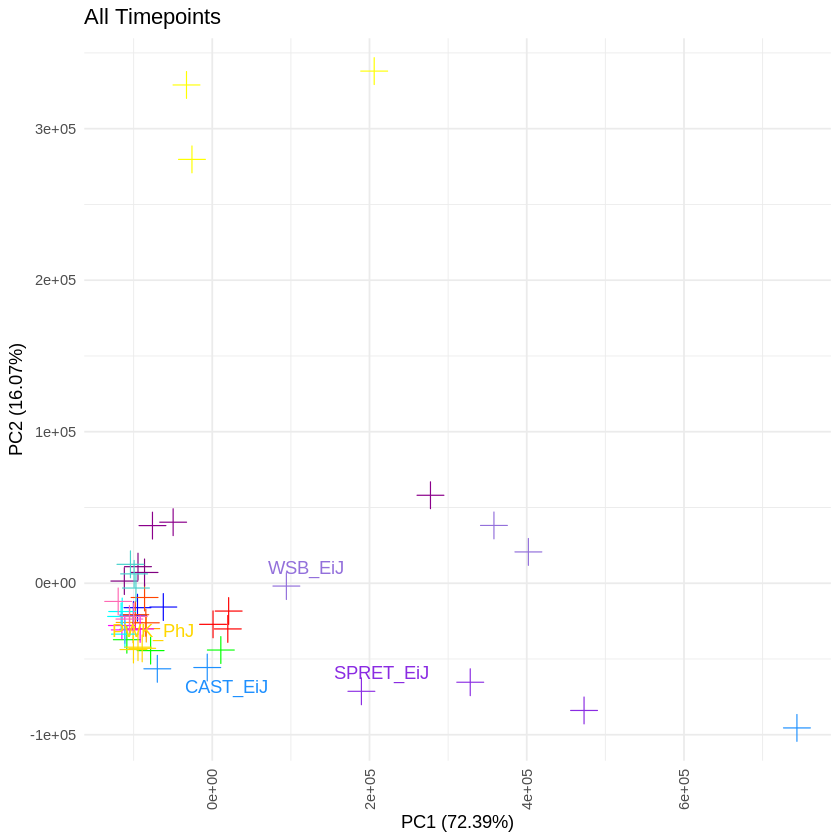

In [13]:

library(ggforce)
# Create the PCA plot
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color = Unique_Strains, shape = Shape)) +
  geom_point(size=5) +
  scale_color_manual(values = custom_colors, breaks = unique(samplenames_order)) + 
  labs(title = "All Timepoints", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  theme_minimal() + 
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +  
  labs(shape = "Timepoint") + labs(color = "Strains")  +
  theme(legend.position = "none", axis.text.x = element_text(angle = 90, vjust = 0.5))  # Rotating x-axis labels




# Filter the data for specific unique strain values
selected_strains <- c("SPRET_EiJ", "WSB_EiJ", "CAST_EiJ", "PWK_PhJ")
filtered_data <- pca_data %>%
  filter(Shape == "E16.5", Unique_Strains %in% selected_strains)



# Adjust the jitter parameters for better label spacing
jitter_amount <- 4
pca_plot_pc1_pc2 <- pca_plot_pc1_pc2 +
  geom_text_repel(
    data = filtered_data %>% distinct(Unique_Strains, .keep_all = TRUE),
    aes(label = Unique_Strains, color = Unique_Strains),
    nudge_x = 0, nudge_y = 0,  # No need for nudge with jitter
    segment.color = "black",
    segment.size = 0.5,
    #arrow = arrow(type = "closed", angle = 90, length = unit(1, "inches")),
    box.padding = unit(0.4, "lines"),  # Adjust padding around labels
    point.padding = unit(0.2, "lines"),  # Adjust padding around points
    force = 10
  )

# Print the modified PCA plot
print(pca_plot_pc1_pc2)
ggsave("E16.5_timepoint_PC1_PC2.pdf", plot = pca_plot_pc1_pc2, width = 3, height = 5)

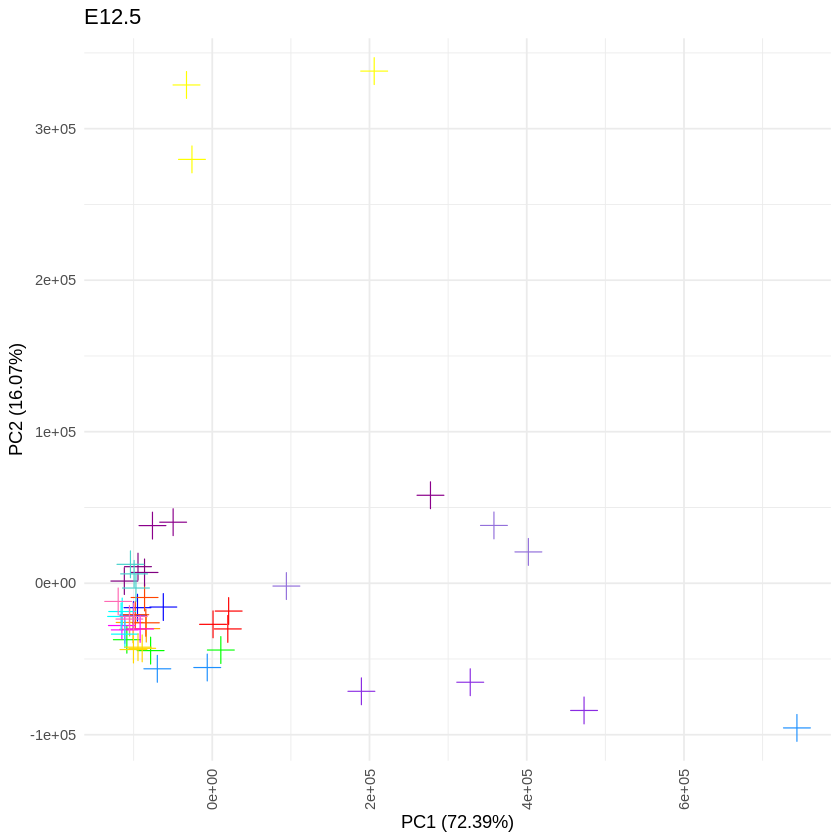

In [14]:
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color = Unique_Strains, shape = Shape)) +
  geom_point(size=5) +
  scale_color_manual(values = custom_colors, breaks = unique(samplenames_order)) + 
  labs(title = "E12.5", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) + 
  theme_minimal() +
  labs(shape = "Timepoint") +
  labs(color = "Strains") +
  theme(legend.position = "none", axis.text.x = element_text(angle = 90, vjust = 0.5))  # Rotating x-axis labels


# Print the modified PCA plot
print(pca_plot_pc1_pc2)
ggsave("E16.5_deseq2_PCA.pdf", pca_plot_pc1_pc2, width = 3, height = 5, units = "in")

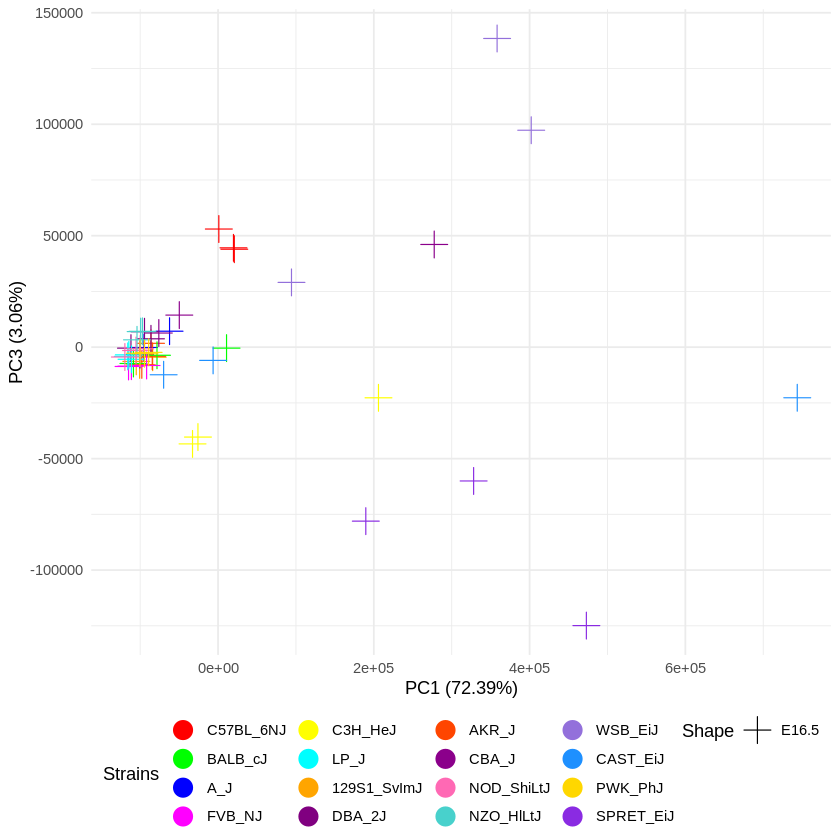

In [15]:
# Existing code (excluding the print command)
pca_plot_pc1_pc3 <- ggplot(pca_data, aes(x = PC1, y = PC3, color = Unique_Strains, shape = Shape)) +
  geom_point(size=5) +
  scale_color_manual(values = custom_colors, breaks = unique(samplenames_order)) + 
  labs(x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[3], 2), "%)", sep = "")) +
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "E16.5" = 17, "D" = 19)) +
  labs(color = "Strains") +
  theme_minimal() +
  theme(legend.direction = "horizontal", legend.position = "bottom")

# Adjust the width of the plot
pca_plot_pc1_pc3 <- pca_plot_pc1_pc3 + theme(legend.box = "horizontal") +
  theme(legend.margin = margin(t = 0, unit = "cm"), 
        legend.spacing = unit(0.2, "cm"))

# Print the plot
print(pca_plot_pc1_pc3)


In [16]:
#install.packages("pheatmap")

[1] "129S1_SvImJ-E16.5.1" "129S1_SvImJ-E16.5.2" "129S1_SvImJ-E16.5.3"
 [4] "A_J-E16.5.1"         "A_J-E16.5.2"         "A_J-E16.5.3"        
 [7] "AKR_J-E16.5.1"       "AKR_J-E16.5.2"       "AKR_J-E16.5.3"      
[10] "BALB_cJ-E16.5.1"     "BALB_cJ-E16.5.2"     "BALB_cJ-E16.5.3"    
[13] "C3H_HeJ-E16.5.1"     "C3H_HeJ-E16.5.2"     "C3H_HeJ-E16.5.3"    
[16] "C57BL_6NJ-E16.5.1"   "C57BL_6NJ-E16.5.2"   "C57BL_6NJ-E16.5.3"  
[19] "CAST_EiJ-E16.5.1"    "CAST_EiJ-E16.5.2"    "CAST_EiJ-E16.5.3"   
[22] "CBA_J-E16.5.1"       "CBA_J-E16.5.2"       "CBA_J-E16.5.3"      
[25] "DBA_2J-E16.5.1"      "DBA_2J-E16.5.2"      "DBA_2J-E16.5.3"     
[28] "FVB_NJ-E16.5.1"      "FVB_NJ-E16.5.2"      "FVB_NJ-E16.5.3"     
[31] "LP_J-E16.5.1"        "LP_J-E16.5.2"        "LP_J-E16.5.3"       
[34] "NOD_ShiLtJ-E16.5.1"  "NOD_ShiLtJ-E16.5.2"  "NOD_ShiLtJ-E16.5.3" 
[37] "NZO_HlLtJ-E16.5.1"   "NZO_HlLtJ-E16.5.2"   "NZO_HlLtJ-E16.5.3"  
[40] "PWK_PhJ-E16.5.1"     "PWK_PhJ-E16.5.2"     "PWK_PhJ-E16.5.3"    
[43] "SPRET_EiJ-E16.5.1"   "SPRET_EiJ-E16.5.2"   "SPRET_EiJ-E16.5.3"  
[46] "WSB_EiJ-E16.5.1"     "WSB_EiJ-E16.5.2"     "WSB_EiJ-E16.5.3"

TGTTAGCCTCTGTCAGCAGTCCTGGGA
GCATTGGTGGTTCAGTGGTAGAATTCT
TGAAGAAACAGACTGGGAGAAAAAAGC
TCCGGTAGAATATGTGCAGATTAAATA
TTGGAAGCAAGTAGAGCTATATGACCT
TACAGAGACAAGAATGACACGGACACC


,129S1_SvImJ-E16.5,A_J-E16.5,AKR_J-E16.5,BALB_cJ-E16.5,C3H_HeJ-E16.5,C57BL_6NJ-E16.5,CAST_EiJ-E16.5,CBA_J-E16.5,DBA_2J-E16.5,FVB_NJ-E16.5,LP_J-E16.5,NOD_ShiLtJ-E16.5,NZO_HlLtJ-E16.5,PWK_PhJ-E16.5,SPRET_EiJ-E16.5,WSB_EiJ-E16.5
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
TGTTAGCCTCTGTCAGCAGTCCTGGGA,22242.05,13022.6538,89.71399,7897.0806,24046.703,36324.483,16686.58280,27822.671,16001.9883,49.20057,14824.124,12479.830,15094.936,497.9557,28.00421,14432.793
GCATTGGTGGTTCAGTGGTAGAATTCT,20199.05,26878.8208,25889.18048,51307.8392,123814.768,93663.285,292040.02323,135752.284,19122.7795,11205.88090,6420.247,10562.260,15224.098,23081.9076,419906.46615,316079.768
TGAAGAAACAGACTGGGAGAAAAAAGC,16040.44,18750.4342,20998.60039,7074.5510,321629.348,13203.664,1396.28867,69569.781,39740.7580,20242.63368,17698.989,24469.694,35679.069,1281.0172,4041.94248,53411.244
TCCGGTAGAATATGTGCAGATTAAATA,13289.50,32829.2291,32516.53807,20168.6707,62002.562,15168.797,82.97369,50912.486,57034.9591,11183.63301,33142.385,27743.970,34611.557,7571.5988,13.08185,54660.471
TTGGAAGCAAGTAGAGCTATATGACCT,13690.80,1147.8197,7334.49066,1783.6060,2711.029,12888.054,12371.27853,7408.181,3156.9853,2405.72882,5527.614,9031.655,3672.825,13785.7989,0.00000,4311.464
TACAGAGACAAGAATGACACGGACACC,10878.24,349.2655,0.00000,373.6403,1032.013,7663.695,0.00000,5046.033,855.1083,0.00000,1894.922,2186.207,1496.085,0.0000,0.00000,2021.251


[1] 38863183

[1] 3959

,129S1_SvImJ-E16.5,A_J-E16.5,AKR_J-E16.5,BALB_cJ-E16.5,C3H_HeJ-E16.5,C57BL_6NJ-E16.5,CAST_EiJ-E16.5,CBA_J-E16.5,DBA_2J-E16.5,FVB_NJ-E16.5,LP_J-E16.5,NOD_ShiLtJ-E16.5,NZO_HlLtJ-E16.5,PWK_PhJ-E16.5,SPRET_EiJ-E16.5,WSB_EiJ-E16.5
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
GCATTGGTGGTTCAGTGGTAGAATTCT,20199.051,26878.82,25889.18,51307.839,123814.77,93663.285,2.920400e+05,135752.28,19122.78,11205.881,6420.247,10562.26,15224.10,23081.908,4.199065e+05,316079.77
TGAAGAAACAGACTGGGAGAAAAAAGC,16040.436,18750.43,20998.60,7074.551,321629.35,13203.664,1.396289e+03,69569.78,39740.76,20242.634,17698.989,24469.69,35679.07,1281.017,4.041942e+03,53411.24
TCCGGTAGAATATGTGCAGATTAAATA,13289.496,32829.23,32516.54,20168.671,62002.56,15168.797,8.297369e+01,50912.49,57034.96,11183.633,33142.385,27743.97,34611.56,7571.599,1.308185e+01,54660.47
TCACCCTGATGAACTGAATACCGCCCC,13840.505,20099.43,13642.04,32005.640,83379.96,99042.834,1.319105e+05,71068.54,11554.61,7617.268,5272.565,6156.63,13061.03,11584.501,1.237345e+05,227546.81
TATAAGGTTCCCGTAACACAGACTGTT,10207.874,10192.63,10569.26,2113.042,63826.18,8778.367,1.852349e+02,24905.61,16582.91,4847.596,11933.093,10081.11,25628.79,10376.935,3.870408e+03,23571.49
CAAAATCTGAGAACGACTCCTGGGCGC,6946.453,33189.91,24101.66,11426.561,49067.40,13210.776,5.930841e+00,24728.19,30191.00,11054.546,8256.537,14760.00,18830.94,38699.822,5.060264e+00,21896.08


,129S1_SvImJ-E16.5,A_J-E16.5,AKR_J-E16.5,BALB_cJ-E16.5,C3H_HeJ-E16.5,C57BL_6NJ-E16.5,CAST_EiJ-E16.5,CBA_J-E16.5,DBA_2J-E16.5,FVB_NJ-E16.5,LP_J-E16.5,NOD_ShiLtJ-E16.5,NZO_HlLtJ-E16.5,PWK_PhJ-E16.5,SPRET_EiJ-E16.5,WSB_EiJ-E16.5,ID
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
GCATTGGTGGTTCAGTGGTAGAATTCT,20199.051,26878.82,25889.18,51307.839,123814.77,93663.285,2.920400e+05,135752.28,19122.78,11205.881,6420.247,10562.26,15224.10,23081.908,4.199065e+05,316079.77,GCATTGGTGGTTCAGTGGTAGAATTCT
TGAAGAAACAGACTGGGAGAAAAAAGC,16040.436,18750.43,20998.60,7074.551,321629.35,13203.664,1.396289e+03,69569.78,39740.76,20242.634,17698.989,24469.69,35679.07,1281.017,4.041942e+03,53411.24,TGAAGAAACAGACTGGGAGAAAAAAGC
TCCGGTAGAATATGTGCAGATTAAATA,13289.496,32829.23,32516.54,20168.671,62002.56,15168.797,8.297369e+01,50912.49,57034.96,11183.633,33142.385,27743.97,34611.56,7571.599,1.308185e+01,54660.47,TCCGGTAGAATATGTGCAGATTAAATA
TCACCCTGATGAACTGAATACCGCCCC,13840.505,20099.43,13642.04,32005.640,83379.96,99042.834,1.319105e+05,71068.54,11554.61,7617.268,5272.565,6156.63,13061.03,11584.501,1.237345e+05,227546.81,TCACCCTGATGAACTGAATACCGCCCC
TATAAGGTTCCCGTAACACAGACTGTT,10207.874,10192.63,10569.26,2113.042,63826.18,8778.367,1.852349e+02,24905.61,16582.91,4847.596,11933.093,10081.11,25628.79,10376.935,3.870408e+03,23571.49,TATAAGGTTCCCGTAACACAGACTGTT
CAAAATCTGAGAACGACTCCTGGGCGC,6946.453,33189.91,24101.66,11426.561,49067.40,13210.776,5.930841e+00,24728.19,30191.00,11054.546,8256.537,14760.00,18830.94,38699.822,5.060264e+00,21896.08,CAAAATCTGAGAACGACTCCTGGGCGC


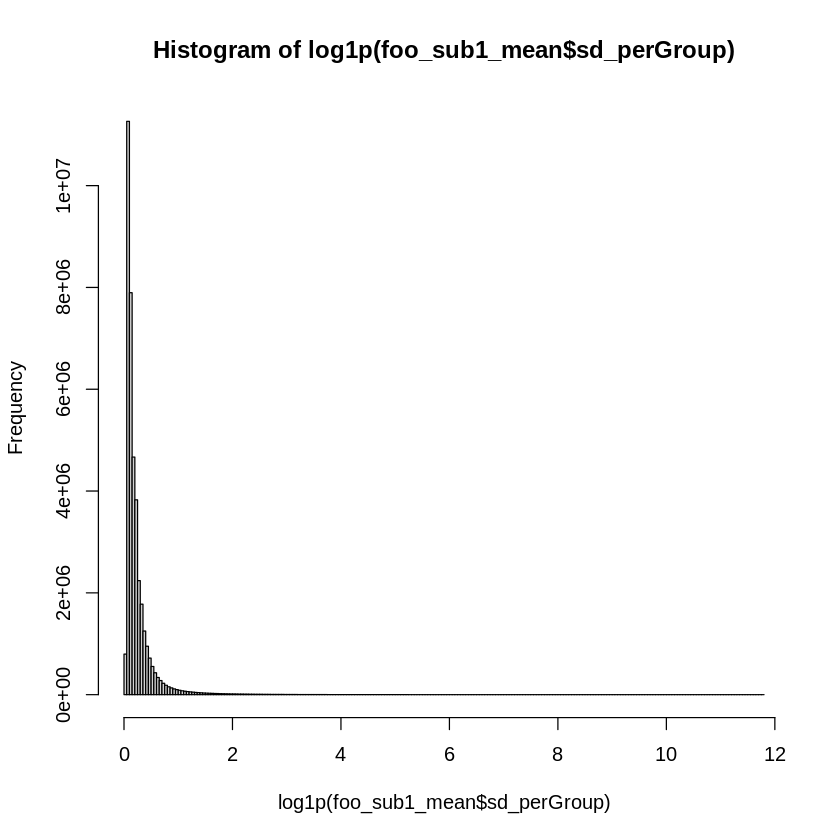

png 
  2

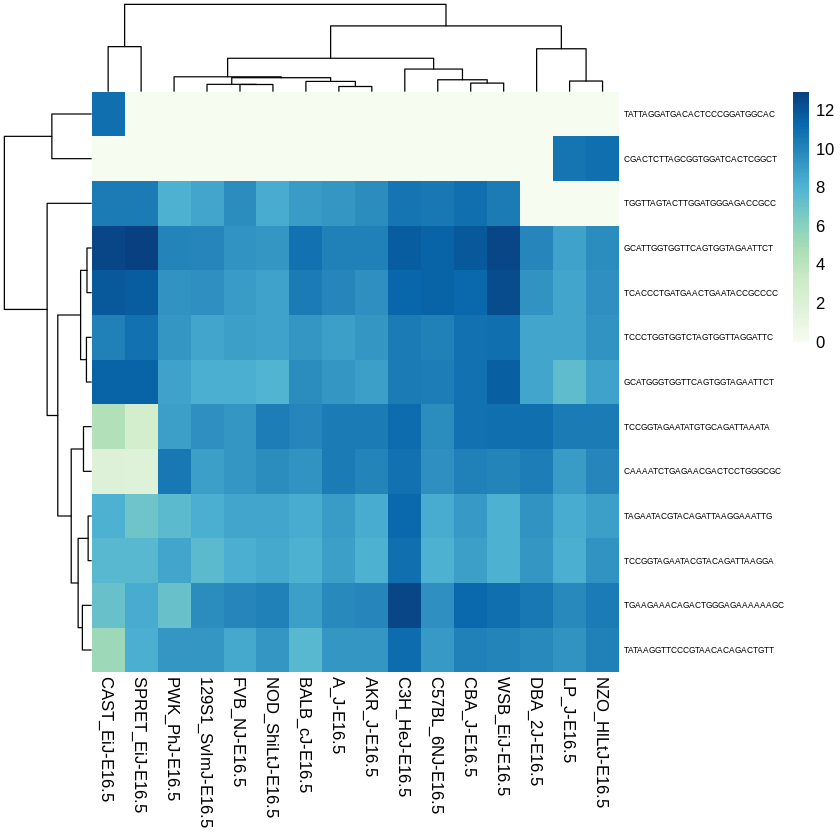

In [17]:

##NEXT IS THE TOP 15% VARIANT miRNA plot on the means. Then the subset more useful miRNA plot
library(pheatmap)
library(gplots)

foo_sub_1 <- as.data.frame.matrix(norm_counts) #convert from matrix to data frame
## use for eg foo$`hPGC_M_Wk9_n1` <- foo$`hPGC-M-Wk9_2` if only want one biol replicate

colnames(foo_sub_1)

head(foo_sub_1[ , grepl( "^129S1_SvImJ-16.5dpc" , names( foo_sub_1 ) ) ])
foo_sub1_mean = data.frame(matrix(NA, nrow = nrow(foo_sub_1), ncol = 0))
row.names(foo_sub1_mean) <- row.names(foo_sub_1)
for (sample in sampleName) {
foo_sub1_mean[sample] <- apply(foo_sub_1[ , grepl(paste0( "^",sample) , names( foo_sub_1 ) ) ], 1, mean)
}
head(foo_sub1_mean) 

foo_sub1_mean$sd_perGroup <- apply(foo_sub1_mean,1,sd)
hist(log1p(foo_sub1_mean$sd_perGroup),breaks = 200)


nrow(foo_sub1_mean)
3959
foo_sub1_mean_top15sd <- foo_sub1_mean[foo_sub1_mean$sd_perGroup>10959,1:16]
head(foo_sub1_mean_top15sd)
foo_sub1_mean_top15sd$ID<-rownames(foo_sub1_mean_top15sd)
head(foo_sub1_mean_top15sd)



save_pheatmap_pdf <- function(x, filename, width=15, height=25) {
    stopifnot(!missing(x))
    stopifnot(!missing(filename))
    pdf(filename, width=width, height=height,paper="special")
    grid::grid.newpage()
    grid::grid.draw(x$gtable)
    dev.off()
}


savePheatmap <- pheatmap(log1p(foo_sub1_mean_top15sd[,1:16]),width=2,height=3, border_color = NA,show_rownames = T, cluster_cols = False, labels_row = foo_sub1_mean_top15sd$ID,fontsize_row = 5, color = hmcol)


save_pheatmap_pdf(savePheatmap,"E16.5_InitialPheatMap.pdf")

png 
  2

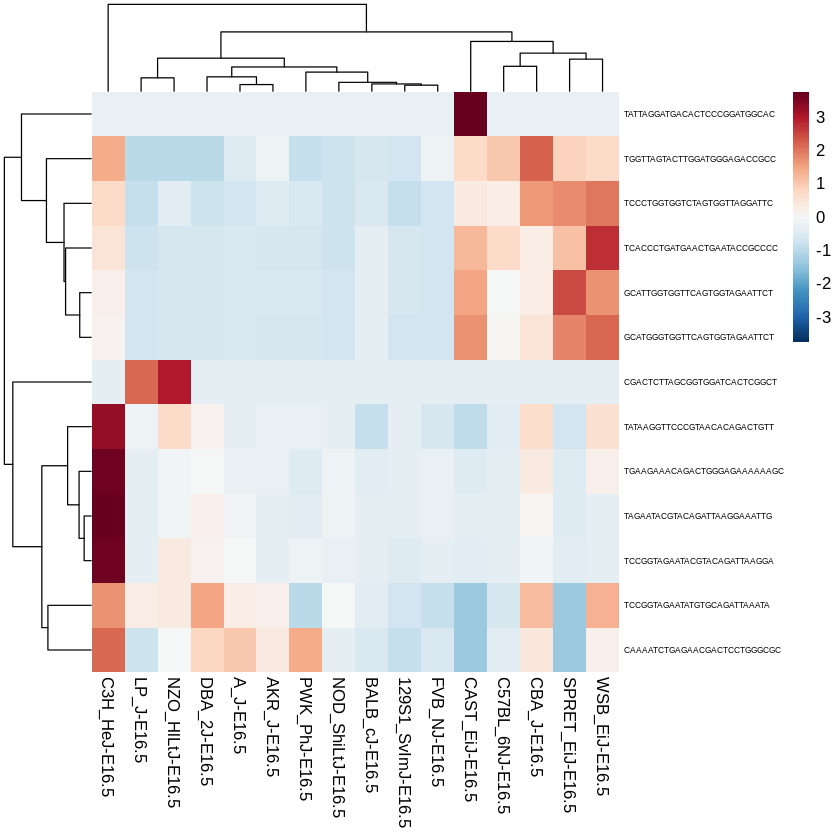

In [18]:
library(gplots)
library(RColorBrewer)
##for z-score
myCol <- rev(colorRampPalette(brewer.pal(11, "RdBu"))(100))



savePheatmapZScore <- pheatmap(foo_sub1_mean_top15sd[,1:16],,width=2,height=3, border_color = NA,show_rownames = T, cluster_cols = False,scale = "row",labels_row = foo_sub1_mean_top15sd$ID,fontsize_row = 5, color = myCol)

save_pheatmap_pdf(savePheatmapZScore,"E16.5_InitialPheatMap_zScore.pdf")